# Unidad 5 · Modelos de series de tiempo

**Qué vas a aprender**
- Qué es una serie **estacionaria** y por qué se modelan los rendimientos y no los precios.
- Leer la **autocorrelación** (ACF y PACF) para identificar un modelo.
- Ajustar modelos **AR**, **MA**, **ARIMA** y **SARIMA**, elegir entre ellos con el AIC y el BIC, y
  revisar sus residuos.
- Evaluar un pronóstico **fuera de la muestra** y proyectar un criptoactivo con su incertidumbre.

**Qué tiene que ver con la app.** El piloto **no pronostica el precio**. Este cuaderno muestra por qué:
los rendimientos diarios de BTC son casi ruido, y ni el mejor ARIMA pronostica mejor que decir "mañana,
cero". En cambio, el tamaño de los movimientos sí tiene memoria, y esa es la puerta a la Unidad 6.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings("ignore")                  # avisos de convergencia de statsmodels

btc = velas("BTC")
lp = np.log(btc["close"]).rename("log_precio")
lp.index = lp.index.tz_localize(None)              # statsmodels prefiere fechas sin zona horaria
lp = lp.asfreq("D")                                # serie diaria: un dato por día, sin huecos
r = lp.diff().dropna().rename("r")
print(len(r), "rendimientos diarios de BTC, del", r.index[0].date(), "al", r.index[-1].date())

2460 rendimientos diarios de BTC, del 2020-01-02 al 2026-09-26


## 1. Estacionariedad: precios frente a rendimientos

Una serie es **estacionaria** si su media y su varianza no cambian con el tiempo: lo que se aprende de
un tramo vale para otro. El precio no lo es (tiene tendencia, y su nivel en 2020 no dice nada del de
2026). El rendimiento diario oscila alrededor de cero.

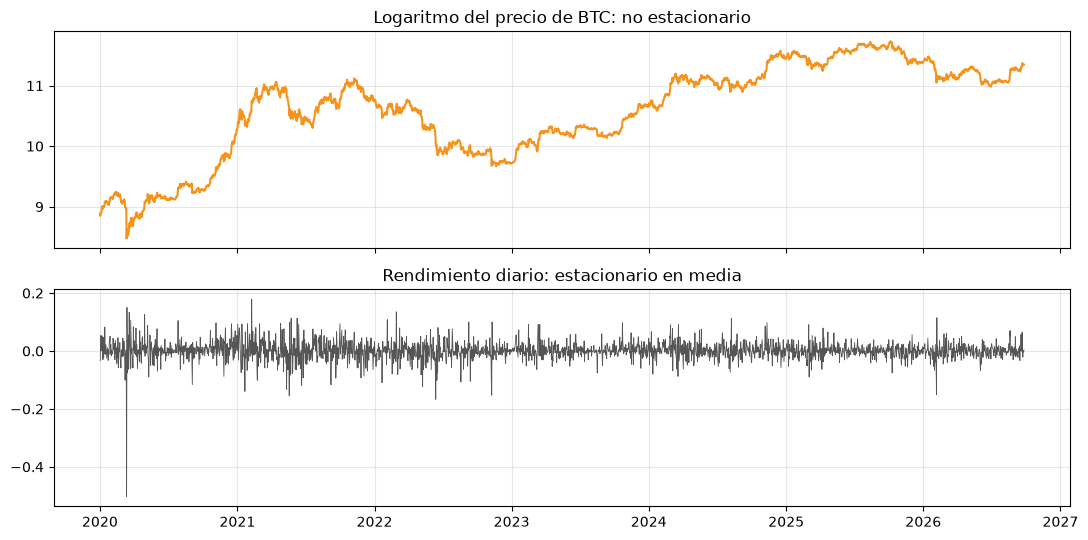

In [3]:
fig, ejes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ejes[0].plot(lp, color=COLORES["BTC"]); ejes[0].set_title("Logaritmo del precio de BTC: no estacionario")
ejes[1].plot(r, color="#555555", linewidth=0.6); ejes[1].set_title("Rendimiento diario: estacionario en media")
plt.tight_layout(); plt.show()

La prueba de **Dickey-Fuller aumentada** (ADF) lo contrasta. Su hipótesis nula es que la serie tiene
una **raíz unitaria** (no es estacionaria): un p-valor pequeño la rechaza. Se usa con constante y
tendencia y con 13 rezagos, que es lo que hace por defecto `adf.test` en R; así los dos lenguajes dan el
mismo estadístico.

In [4]:
for nombre, serie in [("log del precio", lp), ("rendimiento", r)]:
    k = int((len(serie) - 1) ** (1 / 3))
    estad, p, *_ = adfuller(serie, regression="ct", maxlag=k, autolag=None)
    print(f"{nombre:15} ADF = {estad:7.2f}   p-valor = {p:.3f}")

log del precio  ADF =   -1.89   p-valor = 0.659
rendimiento     ADF =  -12.53   p-valor = 0.000


El precio no rechaza la raíz unitaria (p alto); el rendimiento la rechaza con claridad. Por eso se
modela el rendimiento, o, lo que es lo mismo, el log del precio **diferenciado una vez**: la "I" de
ARIMA es ese número de diferencias, *d* = 1.

## 2. ¿Tienen memoria los rendimientos? ACF y PACF

- **ACF** (autocorrelación): la correlación del rendimiento de hoy con el de hace 1, 2, ... días.
- **PACF** (parcial): la misma, descontando los días intermedios.

Las bandas azules marcan lo que se espera por puro azar. Un modelo **AR(p)** deja la PACF cortada tras
*p* rezagos; un **MA(q)**, la ACF cortada tras *q*. Y miremos también los rendimientos **al cuadrado**,
que miden el tamaño del movimiento sin importar el signo.

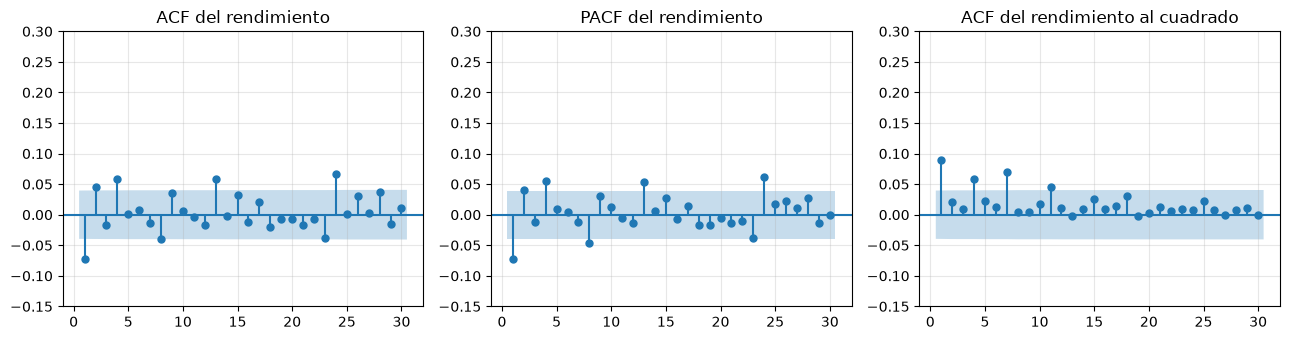

Ljung-Box, 10 rezagos: rendimiento p = 0.000 | al cuadrado p = 3.4e-06


In [5]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.5))
plot_acf(r, lags=30, ax=ejes[0], zero=False, title="ACF del rendimiento")
plot_pacf(r, lags=30, ax=ejes[1], zero=False, title="PACF del rendimiento", method="ywm")
plot_acf(r ** 2, lags=30, ax=ejes[2], zero=False, title="ACF del rendimiento al cuadrado")
for ax in ejes:
    ax.set_ylim(-0.15, 0.3)
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(r, lags=[10])
lb2 = acorr_ljungbox(r ** 2, lags=[10])
print(f"Ljung-Box, 10 rezagos: rendimiento p = {lb['lb_pvalue'].iloc[0]:.3f} | al cuadrado p = {lb2['lb_pvalue'].iloc[0]:.1e}")

La prueba de **Ljung-Box** pregunta si hay alguna autocorrelación en los 10 primeros rezagos. Con toda
la muestra **rechaza** que los rendimientos sean ruido (p ≈ 0): el primer rezago es negativo, una ligera
tendencia a revertir lo de ayer. Pero mira de dónde sale:

In [6]:
for desde in ["2020-01-01", "2020-04-01", "2021-01-01", "2022-01-01"]:
    x = r[r.index >= desde]
    print(f"desde {desde}: rendimiento p = {acorr_ljungbox(x, lags=[10])['lb_pvalue'].iloc[0]:.3f}"
          f" | al cuadrado p = {acorr_ljungbox(x ** 2, lags=[10])['lb_pvalue'].iloc[0]:.1e}")

desde 2020-01-01: rendimiento p = 0.000 | al cuadrado p = 3.4e-06
desde 2020-04-01: rendimiento p = 0.088 | al cuadrado p = 4.9e-26
desde 2021-01-01: rendimiento p = 0.123 | al cuadrado p = 1.2e-27
desde 2022-01-01: rendimiento p = 0.170 | al cuadrado p = 4.1e-18


Basta empezar en abril de 2020 para que la autocorrelación de los rendimientos deje de ser
significativa. La crean unos pocos días de marzo de 2020: −39,5 % el día 12 y +16 % el 13. Un resultado
que depende de dos días no es una regularidad en la que apoyarse.

Los rendimientos **al cuadrado** tienen memoria en todos los periodos: un día agitado anuncia más días
agitados. La dirección es casi impredecible; el tamaño del movimiento, no.

## 3. Modelos AR, MA y ARMA

| Modelo | Ecuación | Idea |
|---|---|---|
| AR(1) | $r_t = \mu + \phi\,(r_{t-1} - \mu) + \varepsilon_t$ | hoy se parece a ayer |
| MA(1) | $r_t = \mu + \varepsilon_t + \theta\,\varepsilon_{t-1}$ | el sobresalto de ayer pesa hoy |
| ARMA(1,1) | las dos cosas | |

`ARIMA(r, order=(p, 0, q))` ajusta un ARMA(p, q) a los rendimientos (con *d* = 0 porque ya están
diferenciados) y estima la media μ (`trend="c"`).

In [7]:
modelos = {}
for orden in [(1, 0, 0), (0, 0, 1), (1, 0, 1)]:
    modelos[orden] = ARIMA(r, order=orden, trend="c").fit()
    print(f"ARIMA{orden}:", {k: round(v, 4) for k, v in modelos[orden].params.items() if k != "sigma2"},
          f"AIC = {modelos[orden].aic:.1f}")
print(modelos[(1, 0, 0)].summary().tables[1])

ARIMA(1, 0, 0): {'const': 0.001, 'ar.L1': -0.0724} AIC = -9949.2
ARIMA(0, 0, 1): {'const': 0.001, 'ma.L1': -0.0684} AIC = -9948.1


ARIMA(1, 0, 1): {'const': 0.001, 'ar.L1': -0.57, 'ma.L1': 0.5016} AIC = -9953.4
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      1.569      0.117      -0.000       0.002
ar.L1         -0.0724      0.013     -5.752      0.000      -0.097      -0.048
sigma2         0.0010   7.98e-06    128.260      0.000       0.001       0.001


El coeficiente AR(1) es pequeño y negativo (−0,07) y, con toda la muestra, significativo. Pero explica
un 0,5 % de la varianza (φ² ≈ 0,005), y ya vimos que depende de marzo de 2020.

R da el mismo coeficiente con un error típico mayor (0,020 frente a 0,013): cada programa lo calcula de
una forma distinta, y con colas gruesas no coinciden. En los dos, el coeficiente queda a más de tres
errores típicos de cero.

## 4. Identificación: elegir *p* y *q* con el AIC y el BIC

Los **criterios de información** premian el ajuste y castigan los parámetros: un modelo con más
parámetros siempre ajusta mejor, pero no siempre pronostica mejor. Menor es mejor. El **BIC** castiga
más que el **AIC**, así que elige modelos más simples.

ARMA(p, q) sobre los rendimientos es lo mismo que **ARIMA(p, 1, q)** sobre el log del precio.

In [8]:
filas = []
for p_ in range(3):
    for q_ in range(3):
        m = ARIMA(r, order=(p_, 0, q_), trend="c").fit()
        filas.append({"modelo": f"ARIMA({p_},1,{q_})", "AIC": m.aic, "BIC": m.bic})
criterios = pd.DataFrame(filas).set_index("modelo")
print("Menor AIC:", criterios["AIC"].idxmin(), "| menor BIC:", criterios["BIC"].idxmin())
(criterios - criterios.min()).round(1)          # diferencia con el mejor de cada columna

Menor AIC: ARIMA(1,1,1) | menor BIC: ARIMA(1,1,0)


,AIC,BIC
modelo,,
"ARIMA(0,1,0)",15.1,5.1
"ARIMA(0,1,1)",5.2,1.0
"ARIMA(0,1,2)",2.8,4.4
"ARIMA(1,1,0)",4.2,0.0
"ARIMA(1,1,1)",0.0,1.6
"ARIMA(1,1,2)",3.9,11.3
"ARIMA(2,1,0)",2.1,3.7
"ARIMA(2,1,1)",2.9,10.3
"ARIMA(2,1,2)",2.6,15.8


La tabla muestra la distancia de cada modelo al mejor; diferencias de menos de 2 puntos no distinguen
modelos.
- El **BIC** prefiere ARIMA(1,1,0), el AR(1) de antes.
- El **AIC** prefiere ARIMA(1,1,1), cuyos coeficientes AR (−0,57) y MA (+0,50) casi se cancelan: un
  síntoma de que el modelo se ajusta al ruido.
- El **paseo aleatorio**, ARIMA(0,1,0) (el precio de mañana es el de hoy más una deriva y ruido), queda
  a 5 puntos de BIC del mejor. Con más de 2400 días, es una diferencia pequeña.

## 5. Evaluar el modelo

**Residuos.** Si el modelo recoge toda la memoria de la serie, sus residuos deben ser ruido blanco
(Ljung-Box con p alto).

In [9]:
ar1 = modelos[(1, 0, 0)]
print(f"Ljung-Box de los residuos del AR(1), 10 rezagos: p = {acorr_ljungbox(ar1.resid, lags=[10])['lb_pvalue'].iloc[0]:.3f}")

Ljung-Box de los residuos del AR(1), 10 rezagos: p = 0.029


**Fuera de la muestra.** Se estima con todo hasta el 26-09-2025 y se pronostica, día a día, el año
siguiente, sin volver a estimar. Tres pronósticos del rendimiento de mañana:
- **Paseo aleatorio**: 0.
- **Media**: la media de entrenamiento.
- **AR(1)**: $\hat\mu + \hat\phi\,(r_{t-1} - \hat\mu)$, con los parámetros de entrenamiento.

Se comparan el error cuadrático medio (RMSE) y el porcentaje de días en que acierta la **dirección**.

In [10]:
corte = pd.Timestamp("2025-09-26")
entreno, prueba = r[r.index <= corte], r[r.index > corte]
fit = ARIMA(entreno, order=(1, 0, 0), trend="c").fit()
mu, phi = fit.params["const"], fit.params["ar.L1"]
ayer = r.shift(1).loc[prueba.index]
pronosticos = {"paseo aleatorio": pd.Series(0.0, index=prueba.index),
               "media": pd.Series(entreno.mean(), index=prueba.index),
               "AR(1)": mu + phi * (ayer - mu)}
pd.DataFrame({nombre: {"RMSE": np.sqrt(((prueba - f) ** 2).mean()),
                       "acierta la dirección": (np.sign(f) == np.sign(prueba)).mean() if nombre != "paseo aleatorio" else np.nan}
              for nombre, f in pronosticos.items()}).T.round(5)

,RMSE,acierta la dirección
paseo aleatorio,0.02360,NaN
media,0.02368,0.48767
AR(1),0.02377,0.49589


Los residuos del AR(1) aún conservan algo de autocorrelación (p ≈ 0,03), otra vez por los días
extremos. Y fuera de la muestra, el AR(1), que era "significativo", pronostica **peor** que el paseo
aleatorio y que la media. El acierto de dirección ronda el 50 %, una moneda al aire. (El paseo
aleatorio pronostica 0, que no tiene dirección.) **Significativo no es lo mismo que útil.**

## 6. SARIMA: cuando hay estacionalidad

Un **SARIMA**$(p,d,q)(P,D,Q)_s$ añade términos que miran *s* períodos atrás. En datos diarios, *s* = 7
recoge un ciclo **semanal**. Los rendimientos no lo tienen, pero el **volumen** sí: la Unidad 2 mostró
que el fin de semana se negocia un 20-35 % menos.

Se compara un ARIMA(1,1,1) con un SARIMA(1,1,1)(1,0,1)₇ sobre el log del volumen en dólares. Se ajustan
hasta el 30-06-2026 y se pronostican los 88 días siguientes de una vez.

ARIMA(1,1,1)           AIC =   2648.4   RMSE de los 88 días = 0.469
SARIMA(1,1,1)(1,0,1)7  AIC =   1406.1   RMSE de los 88 días = 0.366
{'ar.L1': 0.374, 'ma.L1': -0.813, 'ar.S.L7': 0.999, 'ma.S.L7': -0.965, 'sigma2': 0.105}


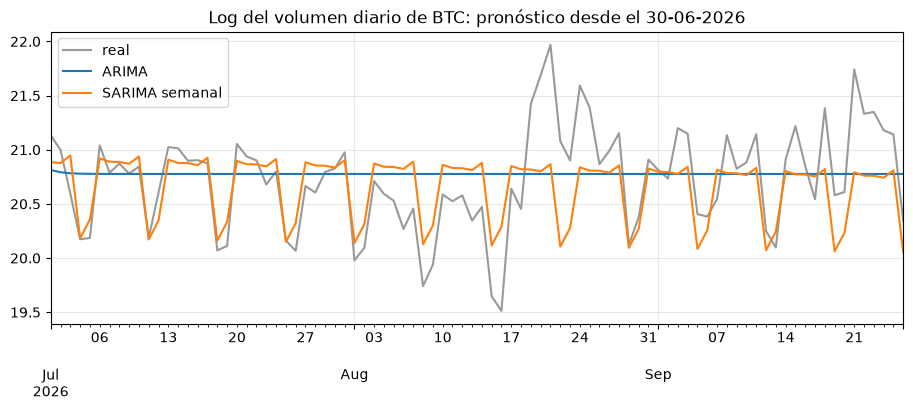

In [11]:
vol = np.log(btc["volume"] * btc["close"]).rename("log_volumen")
vol.index = vol.index.tz_localize(None)
vol = vol.asfreq("D")
v_e, v_p = vol[vol.index <= "2026-06-30"], vol[vol.index > "2026-06-30"]

sin_estacion = ARIMA(v_e, order=(1, 1, 1)).fit()
con_estacion = ARIMA(v_e, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit()
for nombre, m in [("ARIMA(1,1,1)", sin_estacion), ("SARIMA(1,1,1)(1,0,1)7", con_estacion)]:
    f = m.forecast(len(v_p))
    print(f"{nombre:22} AIC = {m.aic:8.1f}   RMSE de los 88 días = {np.sqrt(((v_p - f) ** 2).mean()):.3f}")
print(con_estacion.params.round(3).to_dict())

ax = v_p.plot(color="#999999", label="real", figsize=(11, 3.8))
sin_estacion.forecast(len(v_p)).plot(ax=ax, label="ARIMA")
con_estacion.forecast(len(v_p)).plot(ax=ax, label="SARIMA semanal")
ax.set_title("Log del volumen diario de BTC: pronóstico desde el 30-06-2026"); ax.set_xlabel(""); ax.legend(); plt.show()

El SARIMA tiene un AIC mucho menor y su pronóstico **dibuja la semana**: baja los sábados y domingos.
El ARIMA sin estación pronostica una línea casi plana. Los coeficientes estacionales (`ar.S.L7`,
`ma.S.L7`) recogen el patrón semanal.

## 7. Caso aplicado: proyectar BTC 90 días

El modelo que prefiere el BIC, ARIMA(0,1,0) con deriva, proyecta el log del precio así:

$$\widehat{\ln P}_{T+h} = \ln P_T + h\,\hat\mu \qquad \text{con un intervalo de } \pm 1{,}96\,\hat\sigma\sqrt{h}$$

La incertidumbre crece con la raíz del horizonte. Proyectemos desde el 28-06-2026 hasta el 26-09-2026 y
comparemos con lo que pasó de verdad.

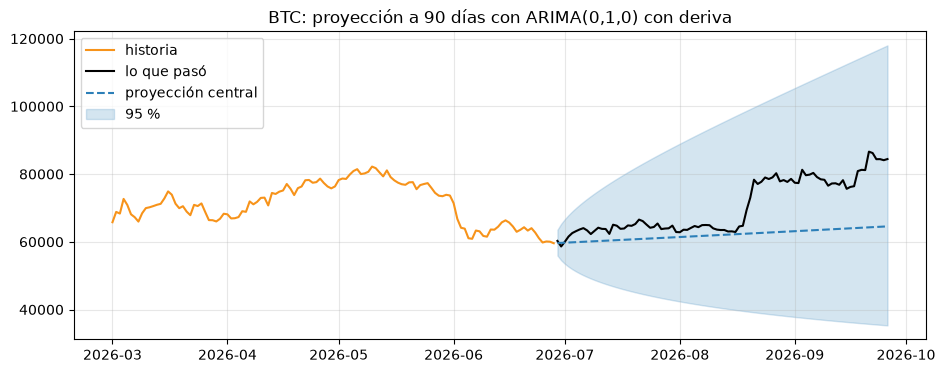

Banda del 95 % a 90 días: de -45% a +83% alrededor del centro
Días en que el precio real quedó dentro de la banda: 100%


In [12]:
origen = pd.Timestamp("2026-06-28")
historia = r[r.index <= origen]
mu_h, sd_h = historia.mean(), historia.std()
h = np.arange(1, 91)
fechas = origen + pd.to_timedelta(h, unit="D")
centro = lp.loc[origen] + h * mu_h
banda = 1.96 * sd_h * np.sqrt(h)
real = np.exp(lp.loc[fechas])

plt.figure(figsize=(11, 4))
plt.plot(np.exp(lp.loc["2026-03-01":origen]), color=COLORES["BTC"], label="historia")
plt.plot(fechas, real, color="black", label="lo que pasó")
plt.plot(fechas, np.exp(centro), color="#2c7fb8", linestyle="--", label="proyección central")
plt.fill_between(fechas, np.exp(centro - banda), np.exp(centro + banda), color="#2c7fb8", alpha=0.2, label="95 %")
plt.legend(); plt.title("BTC: proyección a 90 días con ARIMA(0,1,0) con deriva"); plt.show()

dentro = ((real >= np.exp(centro - banda)) & (real <= np.exp(centro + banda))).mean()
print(f"Banda del 95 % a 90 días: de {np.exp(-banda[-1]) - 1:.0%} a {np.exp(banda[-1]) - 1:+.0%} alrededor del centro")
print(f"Días en que el precio real quedó dentro de la banda: {dentro:.0%}")

La proyección honesta de un criptoactivo no es una línea: es un **abanico**. A 90 días, la banda
del 95 % va de perder un 45 % a ganar más de un 80 %. El centro casi no se mueve, porque la deriva
diaria es diminuta frente a la volatilidad. Esta vez el precio real quedó siempre dentro de la banda,
lo que no quiere decir que el centro acertara: dice que la banda era lo bastante ancha.

## 8. Así lo usa el piloto

- **No pronostica el precio.** Este cuaderno lo justifica: la poca memoria de los rendimientos depende
  de unos días extremos, y el mejor ARIMA no mejora al paseo aleatorio fuera de la muestra.
- **Usa la memoria que sí existe**: la de los rendimientos al cuadrado (sección 2). Su volatilidad
  prevista es un modelo de series de tiempo para la **varianza**, no para la media: la EWMA de la
  Unidad 6.
- **Sus escenarios no usan la banda normal** de la sección 7. Esa banda supone rendimientos normales,
  y las caídas de cripto son más frecuentes de lo que promete la normal. Para la probabilidad de caer
  más de un 10 % el próximo mes, el piloto remuestrea días reales (Unidad 8).

## Ejercicios

1. **ETH y SOL.** Repite la tabla de AIC y BIC con ETH y con SOL. ¿Alguna tiene más memoria que BTC?
2. **Semanal.** Agrega los rendimientos por semana (`r.resample("W").sum()`) y mira su ACF. ¿Cambia algo?
3. **El ARMA(1,1).** Ajusta un ARIMA(1,0,1) y mira sus coeficientes AR y MA. Si son casi iguales y de
   signo contrario, se cancelan: es un síntoma de un modelo sobreajustado.
4. **La banda.** Calcula qué porcentaje de días de 2022 quedó fuera de una banda del 95 % a un día
   (`±1,96 σ`). Si los rendimientos fueran normales, sería el 5 %.